# CROP YIELD PREDICTOIN PER COUNTRY
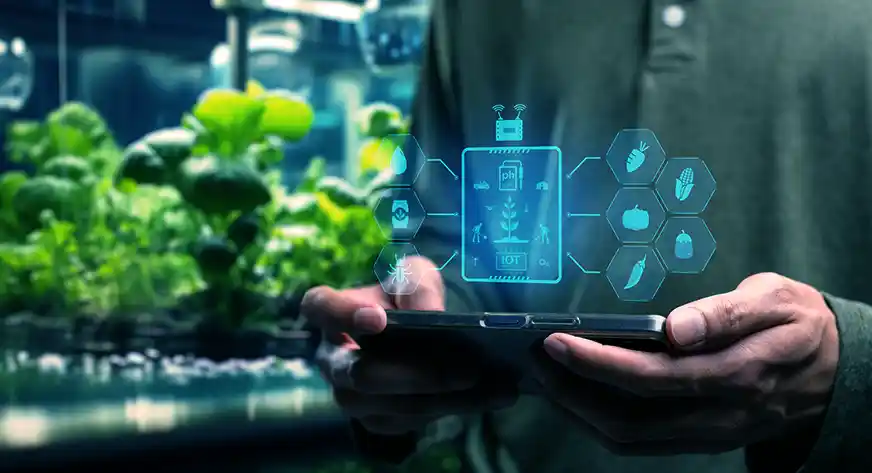
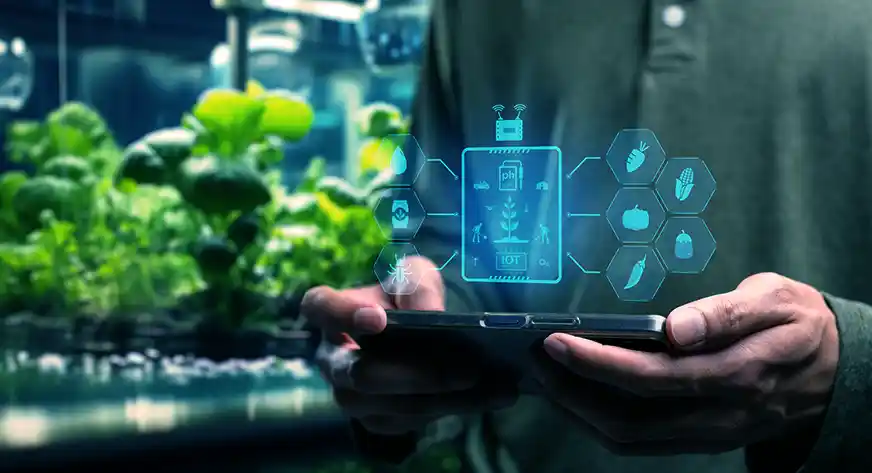

## Important things to know:
- This is a supervised machine learning problem because we have input features as well as output featuers as well in the dataset
- In supervised machine learning it is a regression problem becuase the output feature is numerical

### Import required libraries

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

print("✅ All required libraries are imported successfully")

✅ All required libraries are imported successfully


### Import dataset

In [3]:
df = pd.read_csv('yield_df.csv')

print("✅ Dataset imported successfully")

✅ Dataset imported successfully


In [4]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


### Droping (Unnamed: 0) column

In [5]:
# It will not work because we had already droped that column

df.drop('Unnamed: 0', axis = 1, inplace = True)
df.head()
print('✅ Unecessary column droped')

✅ Unecessary column droped


### EDA:

In [6]:
df.shape

(28242, 7)

Handling missing values

In [7]:
df.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


Handling Duplicate Data:

In [9]:
df.duplicated().sum()

np.int64(2310)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


### Transforming average_rain_fall_mm_per_year
In summary, this code identifies the indices of rows in the DataFrame df where the values in the column 'average_rain_fall_mm_per_year' are not numeric strings. These rows can be considered for removal or further processing, depending on the specific use case.

In [14]:
# In this feature there are some values in integer, some values in float, some values in string so we have to handle it

df['average_rain_fall_mm_per_year']

0        1485.0
1        1485.0
2        1485.0
3        1485.0
4        1485.0
          ...  
28237     657.0
28238     657.0
28239     657.0
28240     657.0
28241     657.0
Name: average_rain_fall_mm_per_year, Length: 25932, dtype: float64

In [17]:
def isStr(obj):
    try:
        float(obj)
        return False
    except:
        return True

In [24]:
to_drop = df[df['average_rain_fall_mm_per_year'].apply(isStr)].index
df = df.drop(to_drop)

In [25]:
df

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.00,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.00,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.00,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.00,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.00,16.37
...,...,...,...,...,...,...,...
28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76


### Graph Frequency VS Area

### yeild_per_country
- We are finding crop production or yield of each country

In [31]:
# Total number of countries in our dataset

len(df['Area'].unique())

101

In [36]:
countries = df['Area'].unique()
yield_per_country = []

for country in countries:
    yield_per_country.append(df[df['Area'] == country]['hg/ha_yield'].sum())

### Yield per country Graph

<Axes: >

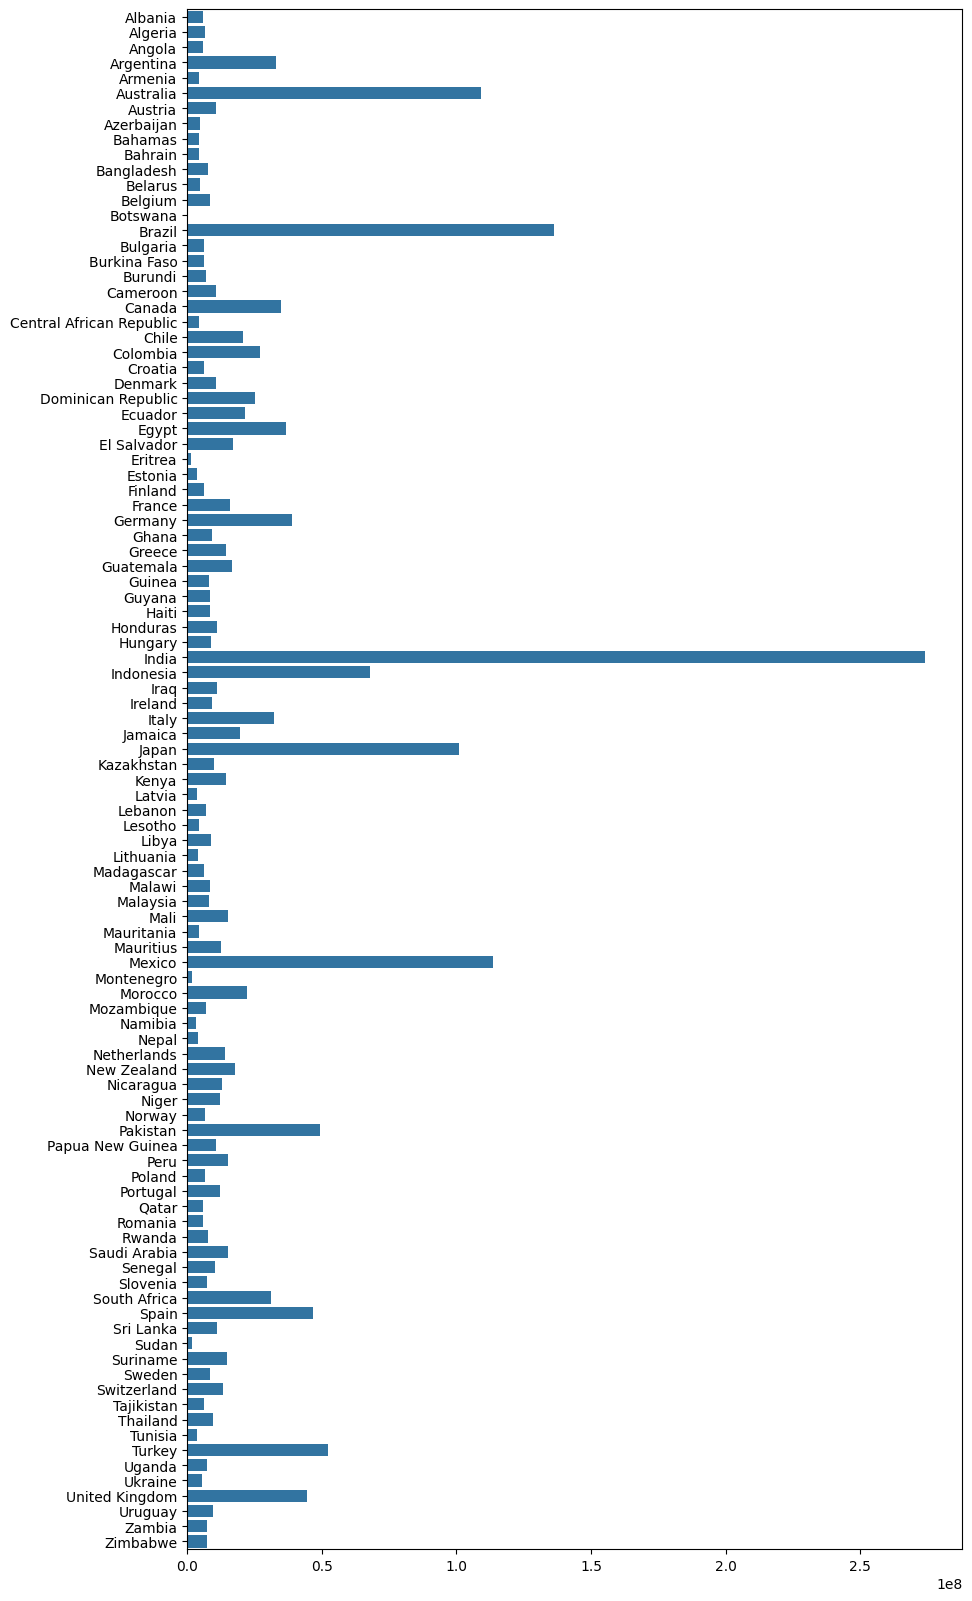

In [41]:
plt.figure(figsize=(10,20))
sns.barplot(x = yield_per_country, y = countries)

### Frequency of each item

### Yield VS Item

In [45]:
# Total number of crop items in the dataset

crops = df['Item'].unique()
len(crops)

10

In [47]:
yield_per_crop = []

for crop in crops:
    yield_per_crop.append(df[df['Item'] == crop]['hg/ha_yield'].sum())

print(yield_per_crop)

[np.int64(142020761), np.int64(785921609), np.int64(127646024), np.int64(52906376), np.int64(49957039), np.int64(106614786), np.int64(275132269), np.int64(310269345), np.int64(58958974), np.int64(86769760)]


<Axes: >

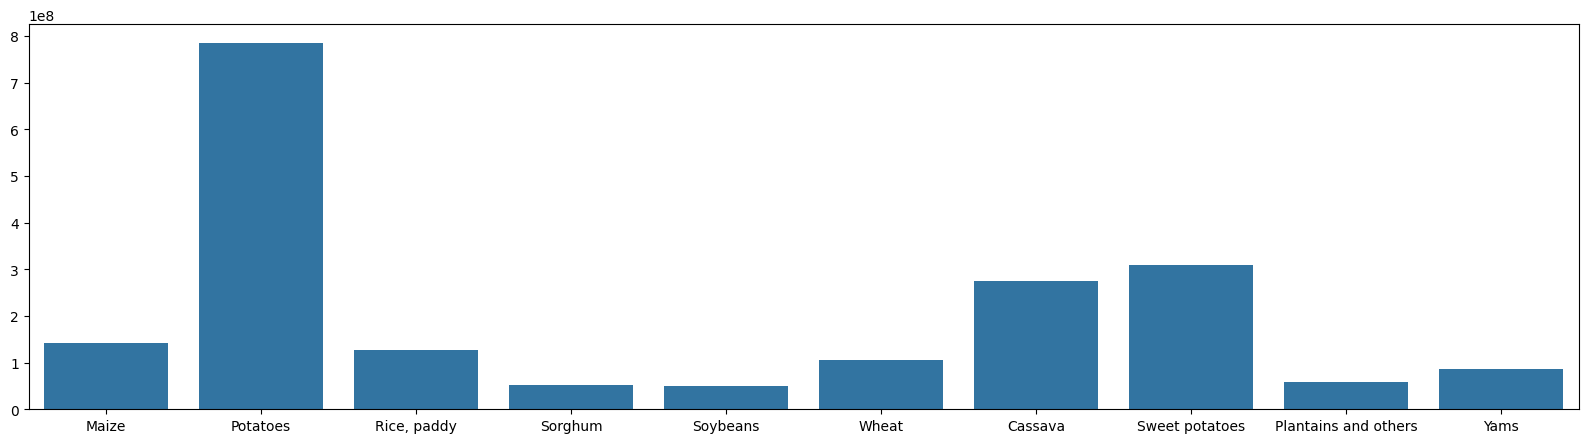

In [52]:
plt.figure(figsize=(20,5))
sns.barplot(x = crops, y = yield_per_crop)

### Train Test Split

Rearranging our features as below

In [59]:
col = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Area', 'Item', 'hg/ha_yield']
df = df[col]
df.head(2)

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item,hg/ha_yield
0,1990,1485.0,121.0,16.37,Albania,Maize,36613
1,1990,1485.0,121.0,16.37,Albania,Potatoes,66667


In [62]:
# splitting dataset to x(input features) y(output feature)

x = df.drop('hg/ha_yield', axis = 1)
y = df['hg/ha_yield']

In [64]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [68]:
print('Train Data Shape')
print('Input features shape: {}, Output feature shape: {}'.format(x_train.shape,y_train.shape))

Train Data Shape
Input features shape: (20745, 6), Output feature shape: (20745,)


In [69]:
print('Test Data Shape')
print('Input features shape: {}, Output feature shape: {}'.format(x_test.shape,y_test.shape))

Test Data Shape
Input features shape: (5187, 6), Output feature shape: (5187,)


### Converting Categorical to Numerical And Scalling The Values

We have two categorical columns in our dataset that are (Area) and (Item), also we will use one hot encoding because the columns data are not in properly order wise to apply other encodings like ordinal encoding

One other thing is that if we use scalling seperately then it will be difficult for us to convert back into proper form for the user and will take time

In [72]:
x_train.head(2)

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item
24234,2000,59.0,3024.11,26.55,Saudi Arabia,Sorghum
9468,2012,652.0,8002.20,18.82,Greece,Sweet potatoes


In [74]:
ohe = OneHotEncoder(drop = 'first')
scaler = StandardScaler()

In [78]:
preprocessor = ColumnTransformer(
    transformers = [
        ('OneHotEncoder', ohe, [4,5]),
        ('Standerization', scaler, [0,1,2,3])
    ],
    remainder = 'passthrough'
)

In [79]:
preprocessor

,transformers,"[('OneHotEncoder', ...), ('Standerization', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [81]:
# This part will make sparce trees with one hot encoding and scaler applied

x_train_final = preprocessor.fit_transform(x_train)
x_test_final = preprocessor.fit_transform(x_test)

In [85]:
x_train_final

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 122877 stored elements and shape (20745, 113)>

### Training Models

In [90]:
models = {
    'lr' : LinearRegression(),
    'lss' : Lasso(),
    'rg' : Ridge(),
    'knr' : KNeighborsRegressor(),
    'dtr' : DecisionTreeRegressor()
}

for name, mod in models.items():
    mod.fit(x_train_final,y_train)
    y_pred = mod.predict(x_test_final)
    print('Model Name : {}, MSE: {}, R2 Score: {}'.format(name, mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)))

Model Name : lr, MSE: 1821769989.669658, R2 Score: 0.7486482648236459


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.317e+10, tolerance: 1.482e+10
  model = cd_fast.sparse_enet_coordinate_descent(


Model Name : lss, MSE: 1822352597.412255, R2 Score: 0.7485678817523145
Model Name : rg, MSE: 1822629015.1241698, R2 Score: 0.7485297440774614
Model Name : knr, MSE: 124881646.97772121, R2 Score: 0.9827699331762387
Model Name : dtr, MSE: 469772132.2749181, R2 Score: 0.9351849897328655


### Model Selection
- We are selecting KNeighborsRegressor model because its mean_square_error is lowest and r2_score is highest

In [ ]:
knr = KNeighborsRegressor()
knr.fit(x_train_final, y_train)
y_pred = knr.predict(x_test_final)

In [117]:

print(mean_squared_error(y_pred, y_test), r2_score(y_pred, y_test))

124881646.97772121 0.9821946739143221


### Predictive System

In [118]:
def prediction(Year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp, Area, Item):
    features = np.array([[Year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp, Area, Item]])

    transformed_features = preprocessor.transform(features)
    predicted_value = knr.predict(transformed_features).reshape(1, -1)
    return predicted_value

In [120]:
Year = 1990
average_rain_fall_mm_per_year = 1485.0
pesticides_tonnes = 121.0
avg_temp = 16.37
Area = 'Albania'
Item = 'Maize'

result = prediction(Year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp, Area, Item)
result

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[28118.]])

### Pickle Files